# Original code

In [1]:
import pandas as pd
from sklearn.impute import SimpleImputer

df = pd.read_csv("dummy_dataset.csv")

print("Original Data:\n", df)

Original Data:
     Age   Salary  Experience_Years  Score  Height_cm  Weight_kg  Projects  \
0   NaN  74131.0                 6  80.92      165.4       87.8         8   
1  48.0  90263.0                 2  69.12      150.6       71.3        14   
2  34.0  46023.0                 1  99.16        NaN       60.4         7   
3  27.0      NaN                12  73.34      159.6       78.4        12   
4  40.0  97221.0                12  93.00      177.3       51.6         9   
5  58.0      NaN                17    NaN      174.4       92.1        14   
6  38.0  30769.0                10  72.52        NaN       72.5         8   
7  42.0      NaN                16  50.66        NaN       69.8         5   
8  30.0  92955.0                15  97.11      165.6       96.3        13   
9  30.0  94925.0                15  78.16      157.3       86.4         2   

  Department  Gender       City  
0    Finance    Male  Bangalore  
1         HR    Male      Delhi  
2         IT    Male  Bangalore  


# Drop rows with missing value

In [2]:
df_dropped_rows = df.copy()

df_dropped_rows = df_dropped_rows.dropna()

print("After Dropping Rows with Missing Values:\n", df_dropped_rows)

After Dropping Rows with Missing Values:
     Age   Salary  Experience_Years  Score  Height_cm  Weight_kg  Projects  \
1  48.0  90263.0                 2  69.12      150.6       71.3        14   
9  30.0  94925.0                15  78.16      157.3       86.4         2   

  Department Gender    City  
1         HR   Male   Delhi  
9         HR   Male  Mumbai  


# Drop columns with missing value

In [3]:
df_dropped_rows = df.copy()

df_dropped_rows = df_dropped_rows.dropna(axis=1)

print("After Dropping Columns with Missing Values:\n", df_dropped_rows)

After Dropping Columns with Missing Values:
    Experience_Years  Weight_kg  Projects
0                 6       87.8         8
1                 2       71.3        14
2                 1       60.4         7
3                12       78.4        12
4                12       51.6         9
5                17       92.1        14
6                10       72.5         8
7                16       69.8         5
8                15       96.3        13
9                15       86.4         2


# Impute numeric features with mean

In [4]:
numeric_imputer = SimpleImputer(strategy='mean')

df_filled = df.copy()

df_filled[['Score', 'Height_cm']] = numeric_imputer.fit_transform(
    df_filled[['Score', 'Height_cm']]
)

print("After Impute:\n", df_filled)

After Impute:
     Age   Salary  Experience_Years      Score   Height_cm  Weight_kg  \
0   NaN  74131.0                 6  80.920000  165.400000       87.8   
1  48.0  90263.0                 2  69.120000  150.600000       71.3   
2  34.0  46023.0                 1  99.160000  164.314286       60.4   
3  27.0      NaN                12  73.340000  159.600000       78.4   
4  40.0  97221.0                12  93.000000  177.300000       51.6   
5  58.0      NaN                17  79.332222  174.400000       92.1   
6  38.0  30769.0                10  72.520000  164.314286       72.5   
7  42.0      NaN                16  50.660000  164.314286       69.8   
8  30.0  92955.0                15  97.110000  165.600000       96.3   
9  30.0  94925.0                15  78.160000  157.300000       86.4   

   Projects Department  Gender       City  
0         8    Finance    Male  Bangalore  
1        14         HR    Male      Delhi  
2         7         IT    Male  Bangalore  
3        12     

# Impute categorical features with mode

In [5]:
categorical_imputer = SimpleImputer(strategy='most_frequent')

df_filled[['Department']] = categorical_imputer.fit_transform(
    df_filled[['Department']]
)

print("After Impute:\n", df_filled)

After Impute:
     Age   Salary  Experience_Years      Score   Height_cm  Weight_kg  \
0   NaN  74131.0                 6  80.920000  165.400000       87.8   
1  48.0  90263.0                 2  69.120000  150.600000       71.3   
2  34.0  46023.0                 1  99.160000  164.314286       60.4   
3  27.0      NaN                12  73.340000  159.600000       78.4   
4  40.0  97221.0                12  93.000000  177.300000       51.6   
5  58.0      NaN                17  79.332222  174.400000       92.1   
6  38.0  30769.0                10  72.520000  164.314286       72.5   
7  42.0      NaN                16  50.660000  164.314286       69.8   
8  30.0  92955.0                15  97.110000  165.600000       96.3   
9  30.0  94925.0                15  78.160000  157.300000       86.4   

   Projects Department  Gender       City  
0         8    Finance    Male  Bangalore  
1        14         HR    Male      Delhi  
2         7         IT    Male  Bangalore  
3        12     

# Hybrid approach

In [6]:
max_missing_allowed = 1
required_non_missing = df.shape[1] - max_missing_allowed

df_threshold = df.copy()

# Keep only rows with at least required_non_missing non-null values
df_threshold = df_threshold.dropna(thresh=required_non_missing)

print("After Dropping Rows with More Than 1 Missing Value:\n", df_threshold)

df_threshold[['Score', 'Height_cm']] = numeric_imputer.fit_transform(
    df_threshold[['Score', 'Height_cm']]
)

df_threshold[['Department']] = categorical_imputer.fit_transform(
    df_threshold[['Department']]
)

print("After Impute:\n", df_threshold)

After Dropping Rows with More Than 1 Missing Value:
     Age   Salary  Experience_Years  Score  Height_cm  Weight_kg  Projects  \
0   NaN  74131.0                 6  80.92      165.4       87.8         8   
1  48.0  90263.0                 2  69.12      150.6       71.3        14   
2  34.0  46023.0                 1  99.16        NaN       60.4         7   
3  27.0      NaN                12  73.34      159.6       78.4        12   
4  40.0  97221.0                12  93.00      177.3       51.6         9   
8  30.0  92955.0                15  97.11      165.6       96.3        13   
9  30.0  94925.0                15  78.16      157.3       86.4         2   

  Department  Gender       City  
0    Finance    Male  Bangalore  
1         HR    Male      Delhi  
2         IT    Male  Bangalore  
3         HR  Female  Bangalore  
4        NaN    Male      Delhi  
8         HR     NaN  Bangalore  
9         HR    Male     Mumbai  
After Impute:
     Age   Salary  Experience_Years  Score  

# Hybrid approach for all numeric and categorical features

In [7]:
max_missing_allowed = 1
required_non_missing = df.shape[1] - max_missing_allowed

df_hybrid = df.copy()

df_hybrid = df_hybrid.dropna(thresh=required_non_missing)

print("After Dropping Rows with More Than 1 Missing Value:\n", df_hybrid)

numeric_features = df_hybrid.select_dtypes(include=['number']).columns.tolist()
categorical_features = df_hybrid.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric Features: {numeric_features}")
print(f"Categorical Features: {categorical_features}")

if numeric_features:
    numeric_imputer = SimpleImputer(strategy='mean')
    df_hybrid[numeric_features] = numeric_imputer.fit_transform(df_hybrid[numeric_features])

if categorical_features:
    categorical_imputer = SimpleImputer(strategy='most_frequent')
    df_hybrid[categorical_features] = categorical_imputer.fit_transform(df_hybrid[categorical_features])

print("\nAfter Hybrid Approach (Drop + Impute All Features):\n", df_hybrid)

After Dropping Rows with More Than 1 Missing Value:
     Age   Salary  Experience_Years  Score  Height_cm  Weight_kg  Projects  \
0   NaN  74131.0                 6  80.92      165.4       87.8         8   
1  48.0  90263.0                 2  69.12      150.6       71.3        14   
2  34.0  46023.0                 1  99.16        NaN       60.4         7   
3  27.0      NaN                12  73.34      159.6       78.4        12   
4  40.0  97221.0                12  93.00      177.3       51.6         9   
8  30.0  92955.0                15  97.11      165.6       96.3        13   
9  30.0  94925.0                15  78.16      157.3       86.4         2   

  Department  Gender       City  
0    Finance    Male  Bangalore  
1         HR    Male      Delhi  
2         IT    Male  Bangalore  
3         HR  Female  Bangalore  
4        NaN    Male      Delhi  
8         HR     NaN  Bangalore  
9         HR    Male     Mumbai  

Numeric Features: ['Age', 'Salary', 'Experience_Years', '

# Min-Max and Z-Score scaling

In [8]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

print("Original data:\n", df_hybrid)

# Initialize scalers
Min_max_scaler = MinMaxScaler()
Z_score_scaler = StandardScaler()

numeric_features = df_hybrid.select_dtypes(include=['number']).columns.tolist()

# Fit and transform the selected numeric columns
scaled_values = Min_max_scaler.fit_transform(
    df_hybrid[numeric_features]
)

standardized_data = Z_score_scaler.fit_transform(
    df_hybrid[numeric_features]
)

# Replace the original values with scaled values
df_scaled = pd.DataFrame(
    scaled_values,
    columns=numeric_features
)

df_standardized = pd.DataFrame(
    standardized_data,
    columns=numeric_features
)

print("Min-Max Normalized Data (using scikit-learn):\n", df_scaled)

print("Z score standardized Data (using scikit-learn):\n", df_standardized)

Original data:
          Age        Salary  Experience_Years  Score   Height_cm  Weight_kg  \
0  34.833333  74131.000000               6.0  80.92  165.400000       87.8   
1  48.000000  90263.000000               2.0  69.12  150.600000       71.3   
2  34.000000  46023.000000               1.0  99.16  162.633333       60.4   
3  27.000000  82586.333333              12.0  73.34  159.600000       78.4   
4  40.000000  97221.000000              12.0  93.00  177.300000       51.6   
8  30.000000  92955.000000              15.0  97.11  165.600000       96.3   
9  30.000000  94925.000000              15.0  78.16  157.300000       86.4   

   Projects Department  Gender       City  
0       8.0    Finance    Male  Bangalore  
1      14.0         HR    Male      Delhi  
2       7.0         IT    Male  Bangalore  
3      12.0         HR  Female  Bangalore  
4       9.0         HR    Male      Delhi  
8      13.0         HR    Male  Bangalore  
9       2.0         HR    Male     Mumbai  
Min-Max

# Visualization of "Score" before and after scaling

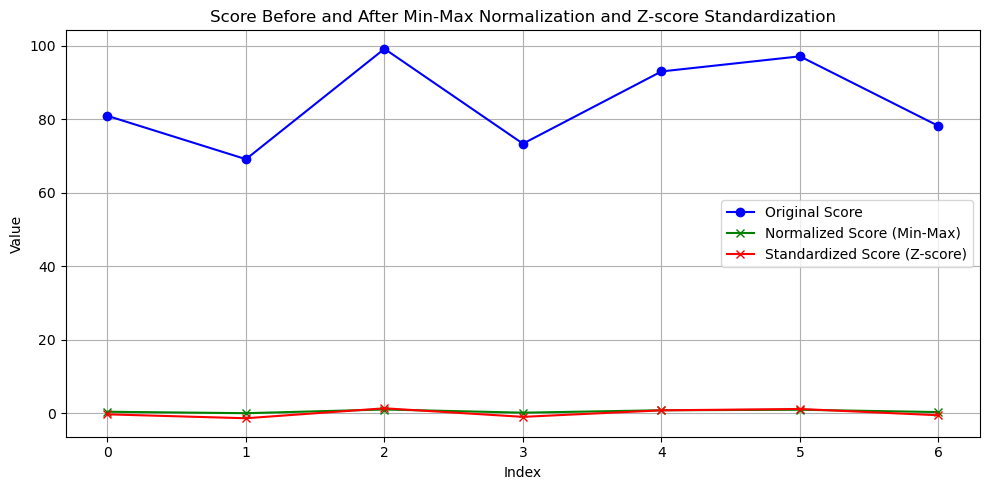

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    df_hybrid['Score'].values,
    label='Original Score',
    marker='o',
    color='blue'
)

plt.plot(
    df_scaled['Score'].values,
    label='Normalized Score (Min-Max)',
    marker='x',
    color='green'
)

plt.plot(
    df_standardized['Score'].values,
    label='Standardized Score (Z-score)',
    marker='x',
    color='red'
)

plt.title('Score Before and After Min-Max Normalization and Z-score Standardization')

plt.xlabel('Index')
plt.ylabel('Value')

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()